# Progetto: Analisi Predittiva del Genere Musicale tramite Sentiment Analysis

## Introduzione
Il presente progetto si propone di analizzare la **sentiment analysis** applicata ai testi musicali al fine di classificarne l'appartenenza di genere. 

Attraverso l’elaborazione del linguaggio naturale (**NLP**), il sistema valuta la carica emotiva dei brani e la confronta con i profili sentimentali medi caratteristici dei diversi generi musicali, determinandone così l’affinità prevalente.

## Dataset e Fonti Dati: Last.fm
Per la realizzazione di questo studio, i metadati relativi ai brani e la loro categorizzazione in generi musicali sono stati ottenuti tramite **Last.fm**.

**Cos'è Last.fm?**
Last.fm è una piattaforma di social music discovery che aggrega dati sull'ascolto globale attraverso un sistema chiamato *scrobbling*. A differenza di altre piattaforme, Last.fm si basa su un sistema di **tagging collaborativo**: sono gli utenti stessi a etichettare artisti e canzoni con tag specifici (es. "rock", "lo-fi", "sad", "energetic").

Nel contesto di questo progetto, Last.fm è stato utilizzato come fonte autorevole per:
1. **Definire i generi musicali:** Grazie ai "Top Tags", è stato possibile associare ogni brano a un genere specifico in modo statistico.
2. **Validazione del Modello:** I tag e le classificazioni di Last.fm fungono da "Ground Truth" (verità di riferimento). Confrontando i sentiment medi calcolati con le aspettative teoriche dei generi, possiamo validare la capacità del modello di distinguere le diverse cariche emotive.

Per l'integrazione dei dati è stata utilizzata la libreria pylast, fondamentale per gestire l'autenticazione della piattaforma, che richiede la generazione di una *api_dignature* basata su hashing MD5 per ogni richiesta che necessiti di autorizzazione

In [ ]:
import os
from dotenv import load_dotenv
import pylast

load_dotenv()

last_fm_key = os.getenv('LAST_FM_KEY')
last_fm_secret = os.getenv('LAST_FM_SECRET')

#network rappresenta la connessione con last.fm, generator gestisce invece lo scambio del token

network = pylast.LastFMNetwork(api_key=last_fm_key, api_secret=last_fm_secret)
generator = pylast.SessionKeyGenerator(network)

url = generator.get_web_auth_url()
print(url)

#attende l'accesso utente su last.fm

input('attesa autorizzazione utente...')

session_key = generator.get_web_auth_session_key(url)
print('Session key: ' + session_key)

Definisco una funzione per ottenere i top 100 brani per un determinato genere.

In [ ]:
def get_top_by_genre(genre):
    tracks = network.get_tag(genre)
    top_tracks = tracks.get_top_tracks(limit=100)

    return top_tracks

In [ ]:
rock_music = get_top_by_genre('rock')

for track in rock_music:
    track_item = track.item
    print(f'{track_item.artist} - {track_item.title}')

Fleetwood Mac - The Chain - 2004 Remaster
Goo Goo Dolls - Iris
Foo Fighters - Everlong
Paramore - Still Into You
Jeff Buckley - Lover, You Should've Come Over
The Killers - Mr. Brightside
Paramore - All I Wanted
Evanescence - Bring Me to Life
Red Hot Chili Peppers - Scar Tissue
Red Hot Chili Peppers - Can't Stop
Coldplay - Sparks
The Cranberries - Linger
Linkin Park - In the End
Harry Styles - Sign of the Times
Paramore - Misery Business
Linkin Park - Faint
My Chemical Romance - Teenagers
Red Hot Chili Peppers - Californication
Linkin Park - Numb
Linkin Park - Somewhere I Belong
The All-American Rejects - Dirty Little Secret
Nickelback - How You Remind Me
Kings of Leon - Sex on Fire
Paramore - Decode
The Police - Every Breath You Take
My Chemical Romance - Helena
Lit - My Own Worst Enemy
Lenny Kravitz - It Ain't Over 'til It's Over
Red Hot Chili Peppers - Under the Bridge
Linkin Park - What I've Done
Three Days Grace - I Hate Everything About You
Paramore - Ain't It Fun
Audioslave - Li

## Acquisizione del Dataset Testuale: Genius API

Una volta ottenuta la lista dei brani tramite Last.fm, il progetto procede con il recupero dei testi originali. A tale scopo è stata scelta la piattaforma **Genius**, interrogata tramite le proprie API ufficiali.

L'implementazione tecnica si avvale della libreria **`lyricsgenius`**, uno strumento essenziale per facilitare la comunicazione con i server di Genius. Grazie a questo wrapper, è stato possibile implementare una pipeline di download automatizzata in grado di gestire le richieste in modo robusto, configurando tempi di *timeout* adeguati per prevenire interruzioni durante lo scraping.

Inoltre, la libreria è stata configurata per effettuare una prima pulizia del dato, rimuovendo metadati non rilevanti (come gli header delle sezioni: *[Chorus]*, *[Verse]*, ecc.), garantendo così un input testuale pulito per la successiva fase di **Sentiment Analysis**.

In [6]:
import pandas as pd
import time
from lyricsgenius import Genius

genius_token = os.getenv('GENIUS_TOKEN')

# Definisco un tempo di timeout, i tentativi per ogni brano, e un periodo di attesa tra una richiesta e l'altra
genius = Genius(genius_token, timeout=15, retries=3, sleep_time=1.0)

# Rimuovo gli header delle sezioni
genius.remove_section_headers = True

# Definisco una funzione per ottenere i testi dei top 100 brani di 5 generi differenti
def get_top_tracks_total():
    genres = ['metal', 'pop', 'hip-hop', 'country', 'reggae']
    total_items = []

    for genre in genres:
        print('recupero brani ' + genre)

        temp_values = get_top_by_genre(genre)

        for track in temp_values:
            track_item = track.item
            title = track_item.title
            artist = track_item.artist.name

            try:
                print(f'cerco {title} - {artist}')
                song = genius.search_song(title, artist)
                lyrics = song.lyrics if song else None

                total_items.append({
                    'genre': genre,
                    'title': title,
                    'artist': artist,
                    'lyrics': lyrics
                })
            
            except Exception as e:
                print(f'Errore durante il recupero di {title}:{artist}')
                continue
        
    
    return pd.DataFrame(total_items)

In [41]:
total_tracks = get_top_tracks_total()

recupero brani metal
cerco My Own Summer (Shove It) - Deftones
cerco Chop Suey! - System of a Down
cerco Toxicity - System of a Down
cerco Sextape - Deftones
cerco Duality - Slipknot
cerco Change (In the House of Flies) - Deftones
cerco Aerials - System of a Down
cerco Blind - Korn
cerco Psychosocial - Slipknot
cerco B.Y.O.B. - System of a Down
cerco Freak on a Leash - Korn
cerco Mascara - Deftones
cerco Before I Forget - Slipknot
cerco Risk - Deftones
cerco Wait and Bleed - Slipknot
cerco Custer - Slipknot
cerco Sugar - System of a Down
cerco Bodies - Drowning Pool
cerco Dragula - Rob Zombie
cerco Borderline - Tame Impala
cerco Hail to the King - Avenged Sevenfold
cerco Around the Fur - Deftones
cerco I-E-A-I-A-I-O - System of a Down
cerco Sonne - Rammstein
cerco Shepherd Of Fire - Avenged Sevenfold
cerco Snuff - Slipknot
cerco Prison Song - System of a Down
cerco Radio/Video - System of a Down
cerco Beauty School - Deftones
cerco Eyeless - Slipknot
cerco Living Dead Girl - Rob Zombie

Salvo tutto in un documento csv per facilitare l'utilizzo dei dati

In [56]:
print(total_tracks)

total_tracks.to_csv('brani.csv', index=False)

      genre                     title                    artist  \
0     metal  My Own Summer (Shove It)                  Deftones   
1     metal                Chop Suey!          System of a Down   
2     metal                  Toxicity          System of a Down   
3     metal                   Sextape                  Deftones   
4     metal                   Duality                  Slipknot   
..      ...                       ...                       ...   
494  reggae                She's Gone  Bob Marley & The Wailers   
495  reggae               Legalize It                Peter Tosh   
496  reggae                      Kaya  Bob Marley & The Wailers   
497  reggae  Zungguzungguguzungguzeng                 Yellowman   
498  reggae           Feeling Alright                Rebelution   

                                                                                                  lyrics  
0    Hey you, big star\nTell me when it's over\n(Cloud)\n\nHey you, big mood\nGuide me t

I testi ottenuti originariamente contengono numerosi caratteri di a capo che potrebbero frammentare l'analisi. Ho quindi proceduto a rimuovere queste interruzioni in ogni brano, normalizzando il testo in un formato più pulito e gestibile per le fasi successive del progetto.

In [ ]:
from IPython.display import display

brani = pd.read_csv('brani.csv')
brani['lyrics'] = brani['lyrics'].apply(lambda x: x.replace('\n', ' '))


display(brani.head())

,genre,title,artist,lyrics
0,metal,My Own Summer (Shove It),Deftones,"Hey you, big star Tell me when it's over (Clou..."
1,metal,Chop Suey!,System of a Down,"We're rolling ""Suicide"" Wake up (Wake up) Gra..."
2,metal,Toxicity,System of a Down,"Conversion, software version 7.0 Looking at li..."
3,metal,Sextape,Deftones,Floating underwater Ever-changing picture Hour...
4,metal,Duality,Slipknot,I push my fingers into my eyes It's the only t...


### Traduzione e Normalizzazione Linguistica

Una parte dei brani ottenuti tramite le API non è in lingua inglese (includendo testi in italiano, spagnolo, ecc.). Poiché gli algoritmi di **Sentiment Analysis** basati su lessico, come **VADER**, sono ottimizzati specificamente per il vocabolario inglese, l'analisi diretta di testi in altre lingue produrrebbe risultati inaccurati o nulli.

Per superare questo limite, è stata implementata una pipeline di pre-processing che prevede:
1. **Rilevamento della lingua:** Identificazione automatica della lingua originale del brano.
2. **Traduzione automatizzata:** Utilizzo della libreria `deep_translator` per convertire i testi non inglesi in inglese, mantenendo il contesto semantico ed emotivo.
3. **Persistenza dei dati:** Salvataggio del dataset processato in un nuovo file `brani_puliti.csv`. 

Quest'ultimo passaggio è fondamentale per garantire l'integrità dei dati grezzi originali e per ottimizzare i tempi di calcolo, evitando di dover ripetere il processo di traduzione nelle esecuzioni successive del notebook.

In [ ]:
from deep_translator import GoogleTranslator
from langdetect import detect, DetectorFactory

DetectorFactory.seed = 0

def translate_lyrics(text):
    try:
        language = detect(text)

        if language == 'en':
            return text

        #impongo un limite di circa 5000 caratteri per non bloccare le chiamate
        print(f'Traduco da lingua: {language}')
        translation = GoogleTranslator(source='auto', target='en').translate(text[:4500])

        time.sleep(1)
        return translation
    except Exception as e:
        print(f'Errore:{e}')
        return text

brani['lyrics'] = brani['lyrics'].apply(translate_lyrics)
brani.to_csv('brani_puliti.csv', index=False)

Traduco da lingua: de
Traduco da lingua: ja
Traduco da lingua: de
Traduco da lingua: de
Traduco da lingua: ja
Traduco da lingua: hr
Traduco da lingua: hr
Traduco da lingua: fr
Traduco da lingua: de
Traduco da lingua: es
Traduco da lingua: pt
Traduco da lingua: pt
Traduco da lingua: pt
Traduco da lingua: pt
Traduco da lingua: pt


# Analisi dei sentiment medi per ogni genere
Avendo adesso un dataset pulito possiamo applicare l'algoritmo VADER per definire il sentiment medio per ogni genere musicale

In [5]:
import nltk
nltk.download('vader_lexicon')

from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()


brani['vader_all'] = brani['lyrics'].apply(lambda x: sia.polarity_scores(str(x)))
brani['pos'] = brani['vader_all'].apply(lambda x: x['pos'])
brani['neg'] = brani['vader_all'].apply(lambda x: x['neg'])
brani['neu'] = brani['vader_all'].apply(lambda x: x['neu'])
brani['compound'] = brani['vader_all'].apply(lambda x: x['compound'])


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/kjiomy/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [6]:
generic_profile = brani.groupby('genre')[['pos', 'neg', 'neu', 'compound']].mean()
print(generic_profile)

              pos       neg       neu  compound
genre                                          
country  0.131101  0.079495  0.789414  0.378838
hip-hop  0.128510  0.105070  0.766420  0.192925
metal    0.095420  0.160060  0.744510 -0.340841
pop      0.159030  0.087940  0.753030  0.444552
reggae   0.156230  0.090160  0.753660  0.348760


### Visualizzazione dei Risultati: Heatmap dei Profili Sentimentali

Per visualizzare in modo efficace le differenze tra i vari generi musicali e facilitare l'identificazione di pattern comuni, è stata generata una **Heatmap** basata sui punteggi medi di sentiment ottenuti.

L'adozione di questa tecnica di visualizzazione permette di:
* **Identificare immediatamente i pattern:** I gradienti cromatici permettono di confrontare a colpo d'occhio le quattro dimensioni del sentiment (*pos, neg, neu, compound*) attraverso i diversi generi musicali.
* **Validare le ipotesi di ricerca:** Consente di verificare visivamente se i generi tipicamente associati a tematiche più forti o aggressive (come il Metal) mostrino effettivamente polarità negative più marcate rispetto a generi considerati "solari" o melodici (come il Pop o il Reggae).
* **Semplificare l'analisi comparativa:** Trasforma una matrice di dati numerici complessi in una rappresentazione grafica intuitiva, rendendo evidenti le divergenze e le affinità emotive che definiscono ogni categoria.

*Nota: La visualizzazione è stata realizzata tramite la libreria **Seaborn**, utilizzando una scala cromatica divergente per evidenziare chiaramente lo scostamento dei valori dalla neutralità.*

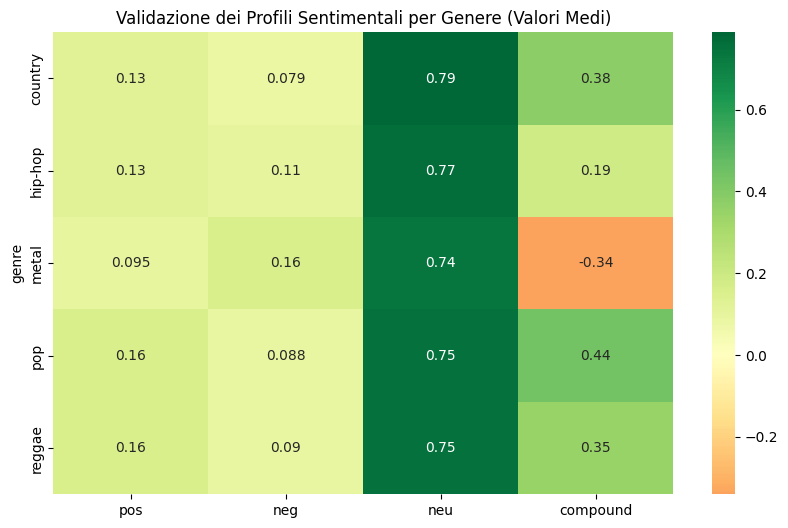

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(generic_profile, annot=True, cmap='RdYlGn', center=0)
plt.title('Validazione dei Profili Sentimentali per Genere (Valori Medi)')

plt.show()

### Analisi Critica dei Risultati
Dalla Heatmap si osserva una forte somiglianza tra i profili di **Pop, Reggae e Country**. Questo fenomeno è spiegabile attraverso due fattori:
1. **Omogeneità Lessicale:** Questi generi condividono un vocabolario orientato a sentimenti positivi o descrittivi, che l'algoritmo VADER interpreta con punteggi di `compound` simili.
2. **Il Limite del Testo:** La distinzione tra questi generi risiede maggiormente nella componente sonora (ritmo, arrangiamento) piuttosto che in quella testuale.

Al contrario, il genere **Metal** si distingue nettamente con un `compound` medio negativo ($\approx -0.34$), confermando la capacità del modello di identificare almeno le macro-differenze emotive tra generi con stili lirici diametralmente opposti.

Definisco adesso una funzione che prende in input un file contentente il testo di una canzone, traduce il testo se necessario, applica VADER per stabilire i valori di sentimen, e stabilisce un 'classifica' dei generi più affini

In [ ]:
import numpy as np

def trova_genere_affine(percorso):
    try:
        with open(percorso, 'r', encoding='utf-8') as f:
            testo = f.read()
    except FileNotFoundError:
        return "Errore: File non trovato."

    clean_text = testo.replace('\n', ' ')
    translated_text = translate_lyrics(clean_text)

    #trasformo in un vettore i valori dei sentiment, per verificare la vicinanza con gli altri generi
    new_score = sia.polarity_scores(translated_text)
    new_vector = np.array([new_score['pos'], new_score['neg'], new_score['neu'], new_score['compound']])

    distances = {}

    for genre, row in generic_profile.iterrows():
        genre_vector = np.array([row['pos'], row['neg'], row['neu'], row['compound']])

        distance = np.linalg.norm(new_vector - genre_vector)
        distances[genre] = distance
    
    rank = sorted(distances.items(), key=lambda x: x[1])
    return rank, new_score


In [14]:
def print_genre_similarity(filepath):
    classifica, punteggio = trova_genere_affine(filepath)

    print(f'Risultati per: [{filepath}]')
    print(f'Punteggi VADER del testo: {punteggio}')
    print(f'Distanza per genere:')

    for genere, dist in classifica:
        print(f'- {genere.upper()}: {dist:.4f}')

# Test
Effettuo adesso dei test con brani di diversi generi, per verificare l'accuratezza dell'algoritmo

In [15]:
print_genre_similarity('watch_the_world_burn.txt')

Risultati per: [watch_the_world_burn.txt]
Punteggi VADER del testo: {'neg': 0.239, 'neu': 0.659, 'pos': 0.101, 'compound': -0.9984}
Distanza per genere:
- METAL: 0.6678
- HIP-HOP: 1.2039
- REGGAE: 1.3598
- COUNTRY: 1.3929
- POP: 1.4550


In [16]:
print_genre_similarity('marinella.txt')

Traduco da lingua: it
Risultati per: [marinella.txt]
Punteggi VADER del testo: {'neg': 0.076, 'neu': 0.641, 'pos': 0.283, 'compound': 0.997}
Distanza per genere:
- POP: 0.5773
- COUNTRY: 0.6536
- REGGAE: 0.6702
- HIP-HOP: 0.8288
- METAL: 1.3575


In [17]:
print_genre_similarity('in_my_solitude.txt')

Risultati per: [in_my_solitude.txt]
Punteggi VADER del testo: {'neg': 0.246, 'neu': 0.596, 'pos': 0.158, 'compound': -0.9014}
Distanza per genere:
- METAL: 0.5896
- HIP-HOP: 1.1168
- REGGAE: 1.2697
- COUNTRY: 1.3057
- POP: 1.3643


In [18]:
print_genre_similarity('country_road.txt')

Risultati per: [country_road.txt]
Punteggi VADER del testo: {'neg': 0.0, 'neu': 0.968, 'pos': 0.032, 'compound': 0.6712}
Distanza per genere:
- POP: 0.3485
- COUNTRY: 0.3654
- REGGAE: 0.4165
- HIP-HOP: 0.5383
- METAL: 1.0506


### Conclusioni sulla Validazione
I test effettuati confermano l'efficacia della metodologia:
* **Esempio Metal:** Il brano *Watch the World Burn* mostra una distanza minima dal profilo **METAL** (0.6678), validando la capacità del sistema di riconoscere l'aggressività testuale.
* **Esempio Pop/Melodico:** Il brano *Marinella* (tradotto dall'italiano) è risultato più affine al genere **POP** (0.5773), coerente con la sua natura melodica.
* **Esempio** il brano *In my Solitude* seppure un brano jazz, ha un testo con sentiment molto negativo, l'assenza di feature musicali porta ad una classificazione nel genere metal.
* **Coerenza Statistica:** La distribuzione dei punteggi `compound` rispecchia le caratteristiche intrinseche dei generi analizzati (es. Metal negativo vs Pop positivo), confermando la bontà dei dati estratti da Last.fm come base di confronto.